# Results Parser

In [1]:
import pandas
import matplotlib.pyplot as plt

## Collating all stages results into 1 table

In [ ]:
FILE_PREFIX = "hmm-em-upos"
NUM_STAGES = 100

# Get all results
all_results = []
for i in range(0, NUM_STAGES):
    file_path = f"./results/{FILE_PREFIX}/hmm-em-upos.{i}.csv"
    try:
        df = pandas.read_csv(file_path)
        df["stage"] = i
        all_results.append(df)
    except FileNotFoundError:
        print(f"Stopping: Results for stage {i} not found")
        break

# Save all resuluts
all_results = pandas.concat(all_results)
all_results.to_csv(f"./results/{FILE_PREFIX}/hmm-em-upos-all-stages.csv", index=False)

all_results.head()

## Load actual full dataset stats

In [13]:
whole_dataset_results = pandas.read_csv("./results/hmm-em-upos/hmm-em-upos.csv")
display(whole_dataset_results)

,id,sentence,VI,normalized-VI,homogeneity,completeness,V-score
0,0,-,6.670068,0.92321,0.080203,0.073655,0.07679


## Draw Graphs

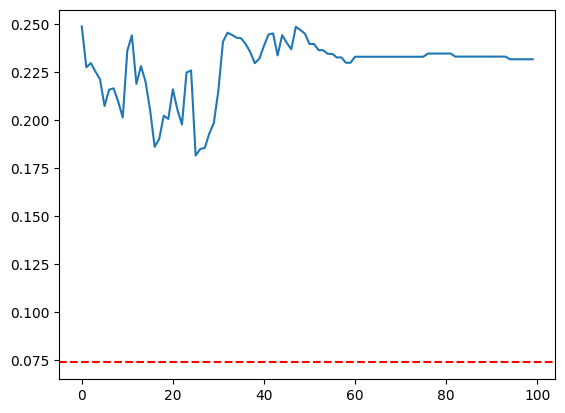

In [22]:
FIELD = "completeness"

plt.plot(all_results["stage"], all_results[FIELD])
plt.axhline(
    y=whole_dataset_results[FIELD].iloc[0],
    color='r',
    linestyle='--',
)
plt.show()
